<a href="https://colab.research.google.com/github/F-Boivin/ProyectoDSParteI-Final-Boivin/blob/main/ProyectoParteIII%2BBoivin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Data Science I — Parte III: Modelo de Clasificación
## Dataset UCI Bank Marketing

**Alumno:** Felipe Boivin  
**Curso:** Data Science I — Coderhouse  
**Dataset:** [bank.csv — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing)

**Objetivo:** Construir un modelo de Machine Learning (Random Forest) para predecir si un cliente contratará un depósito a plazo fijo, complementando el análisis exploratorio realizado en la Parte I.

## 1. Introducción y Objetivo

**Objetivo:** Predecir si un cliente contratará un depósito a plazo fijo, basándose en sus características demográficas, financieras y de campaña.

## 2. Importar Librerías

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve,
                             auc, roc_auc_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

In [39]:
# Configuraciones para visualización
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Carga de Datos

In [40]:
# Carga del dataset desde GitHub
url = 'https://raw.githubusercontent.com/F-Boivin/ProyectoDSParteI-Final-Boivin/refs/heads/main/bank.csv'
df = pd.read_csv(url, sep=';')
print(f'Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')
df.head()

Dataset cargado: 4521 filas, 17 columnas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


## 4. Hipótesis

#### **Hipótesis Nula (H0):** Las características demográficas, financieras y de campaña del cliente no son suficientes para predecir la contratación de un depósito a plazo con una precisión significativamente mejor que el azar.

#### **Hipótesis Alternativa (H1):** Es posible construir un modelo de clasificación (Random Forest) que prediga la contratación del depósito con una Accuracy superior al 75% y un AUC superior a 0.5, utilizando las características disponibles (excluyendo la variable `duration`).

**Nota sobre la exclusión de `duration`:** La duración de la llamada solo se conoce después de que la llamada ocurre, por lo que no puede utilizarse en un modelo predictivo real. Su exclusión aporta mayor validez práctica al modelo.

## 5. Análisis Exploratorio Breve

Se realizó un EDA completo en la Parte I de este proyecto. A continuación se presenta un resumen enfocado en las variables más relevantes para la construcción del modelo.

### 5.1. Distribución de la variable objetivo ('y')

In [42]:
# Distribución de la variable objetivo
print('Distribución de la variable objetivo (y):')
print(df['y'].value_counts())
print(f'\nProporción: {df["y"].value_counts(normalize=True).round(4)}')

Distribución de la variable objetivo (y):
y
no     4000
yes     521
Name: count, dtype: int64

Proporción: y
no     0.8848
yes    0.1152
Name: proportion, dtype: float64


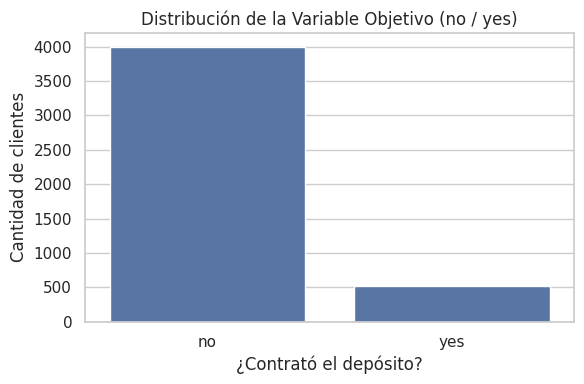

In [43]:
# Distribución visual de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df)
plt.title('Distribución de la Variable Objetivo (no / yes)')
plt.xlabel('¿Contrató el depósito?')
plt.ylabel('Cantidad de clientes')
plt.tight_layout()
plt.show()

### 5.2. Análisis de variables numéricas

In [44]:
# Identificar variables numéricas (excluyendo 'y')
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f'Variables numéricas: {numerical_cols}')

Variables numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


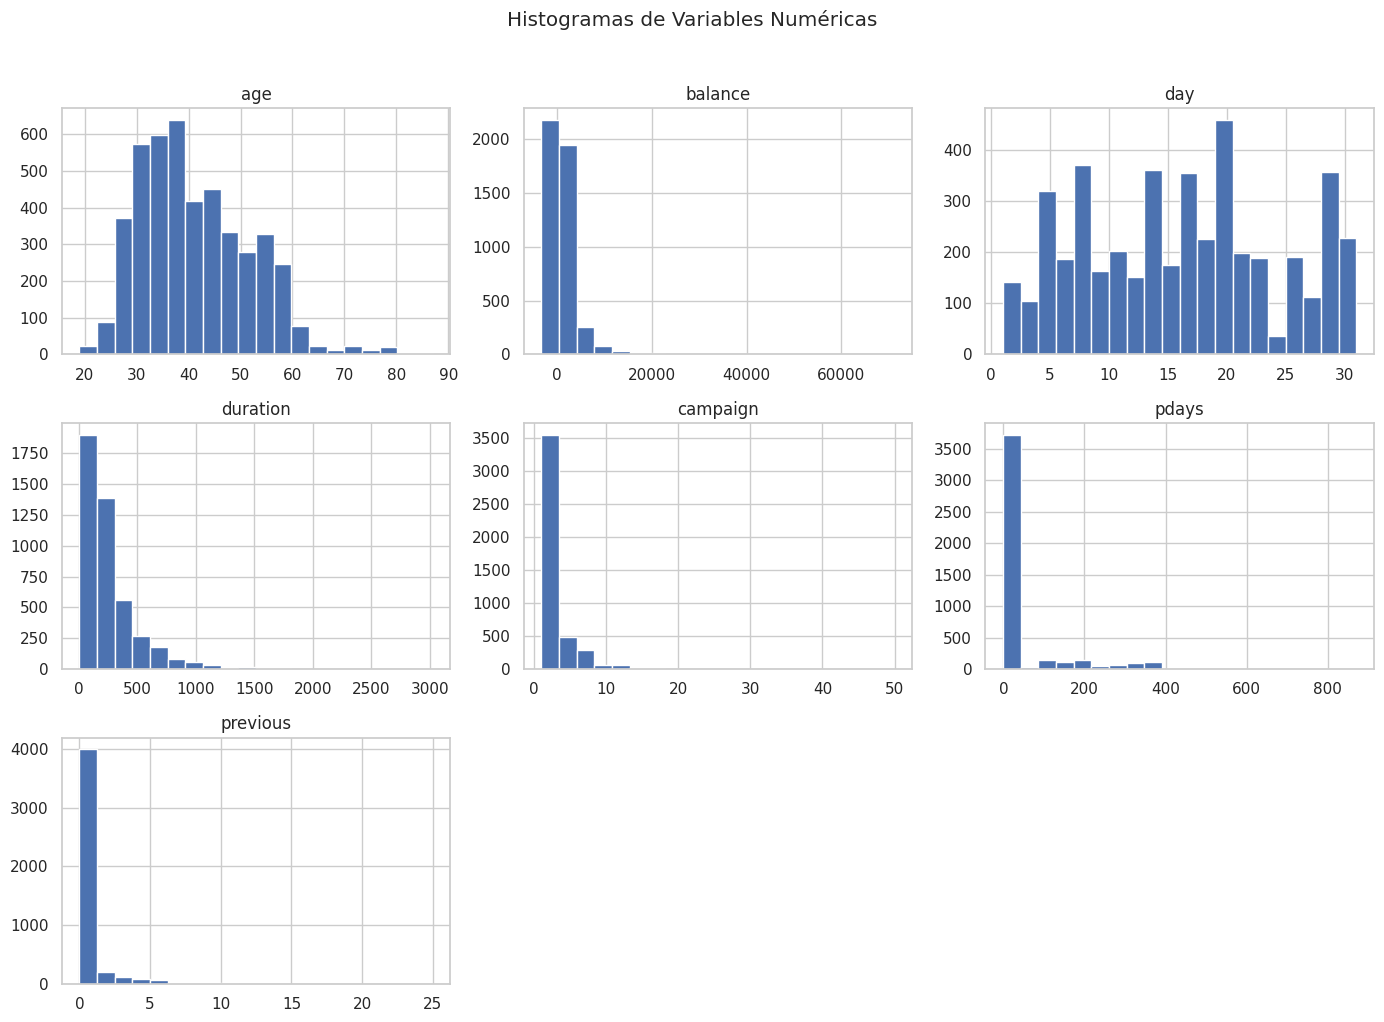

In [45]:
# Histogramas de variables numéricas
df[numerical_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle('Histogramas de Variables Numéricas', y=1.02)
plt.tight_layout()
plt.show()

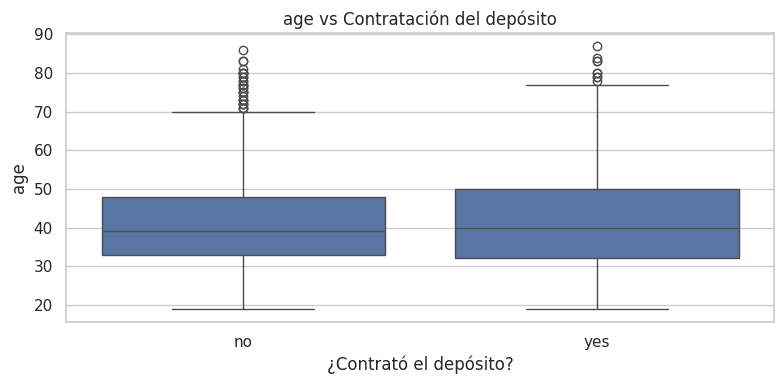

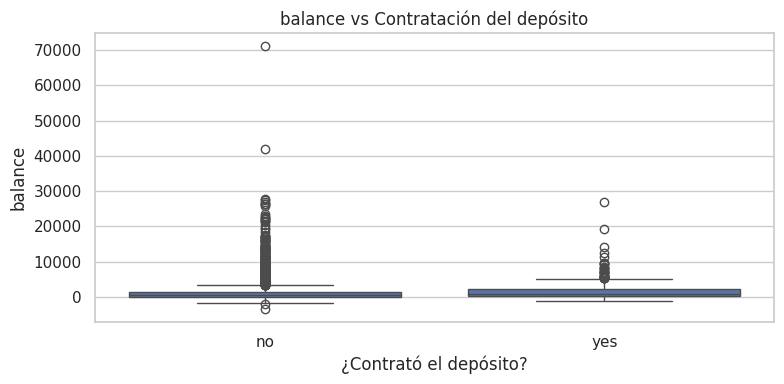

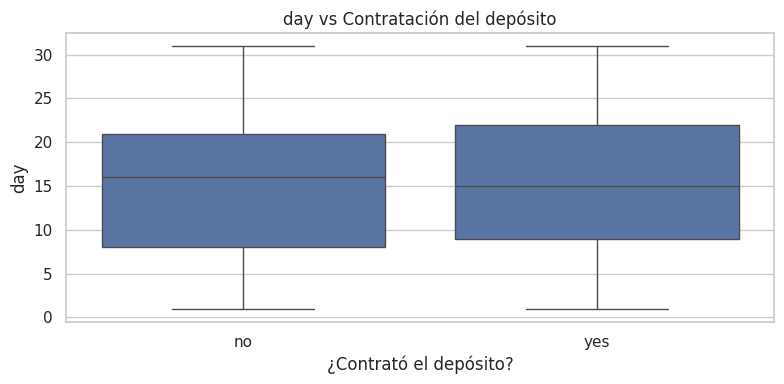

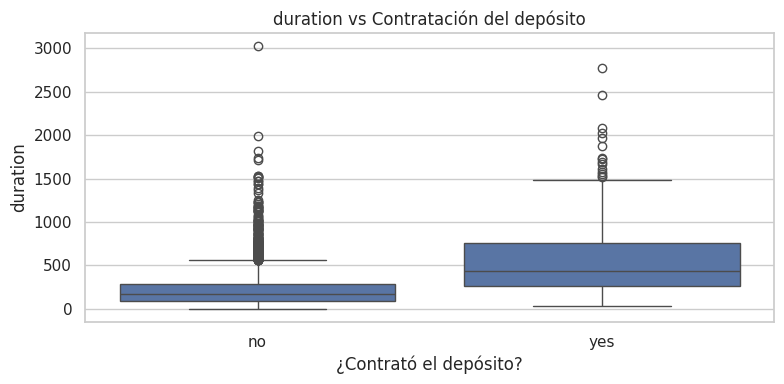

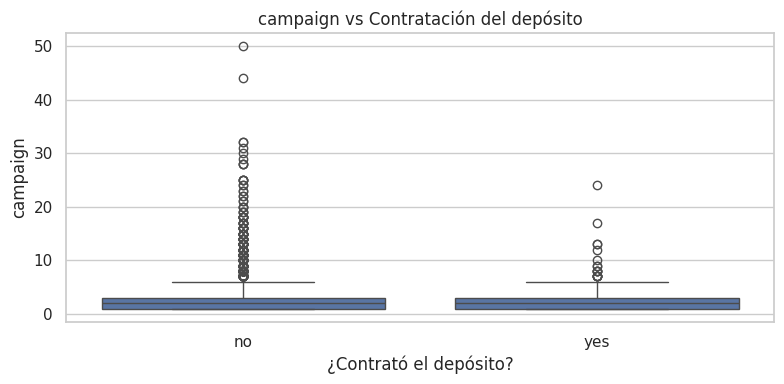

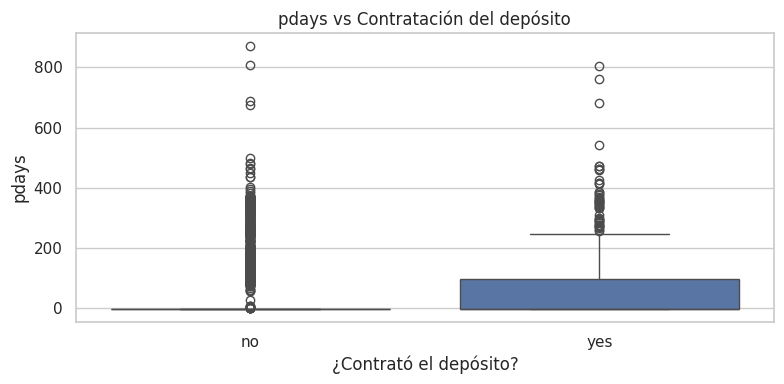

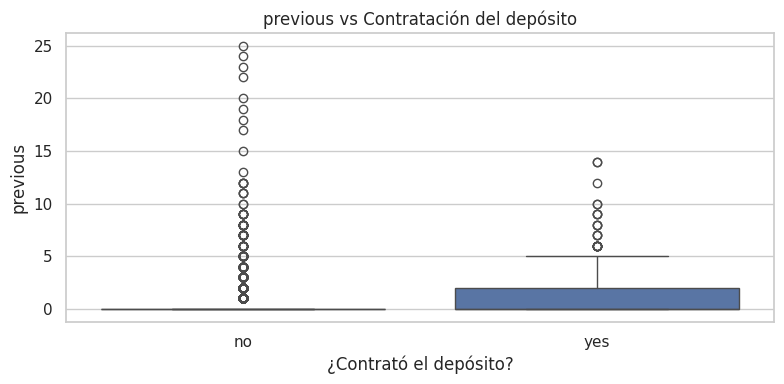

In [46]:
# Boxplots de variables numéricas vs variable objetivo
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='y', y=col, data=df)
    plt.title(f'{col} vs Contratación del depósito')
    plt.xlabel('¿Contrató el depósito?')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### 5.3. Análisis de variables categóricas

In [47]:
# Identificar variables categóricas (excluyendo 'y')
categorical_cols_eda = df.select_dtypes(include='object').columns.tolist()
categorical_cols_eda.remove('y')
print(f'Variables categóricas: {categorical_cols_eda}')

Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


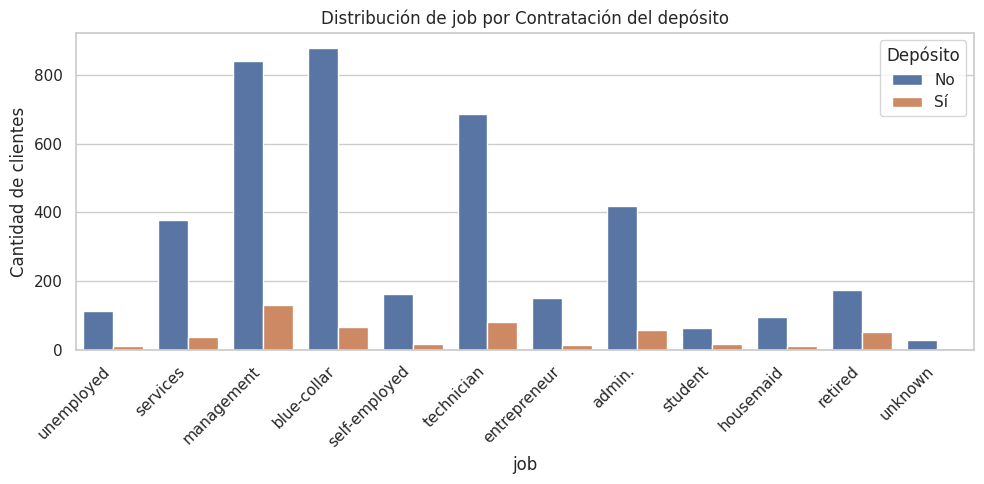

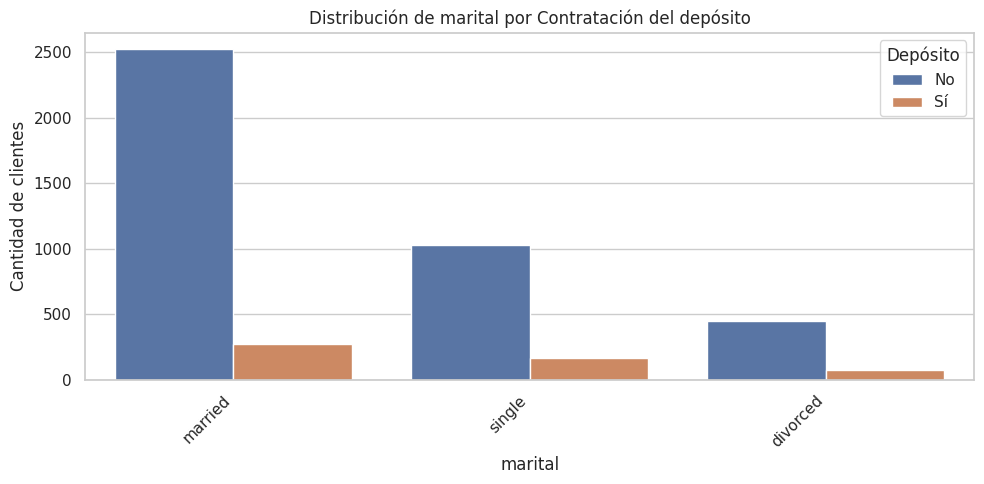

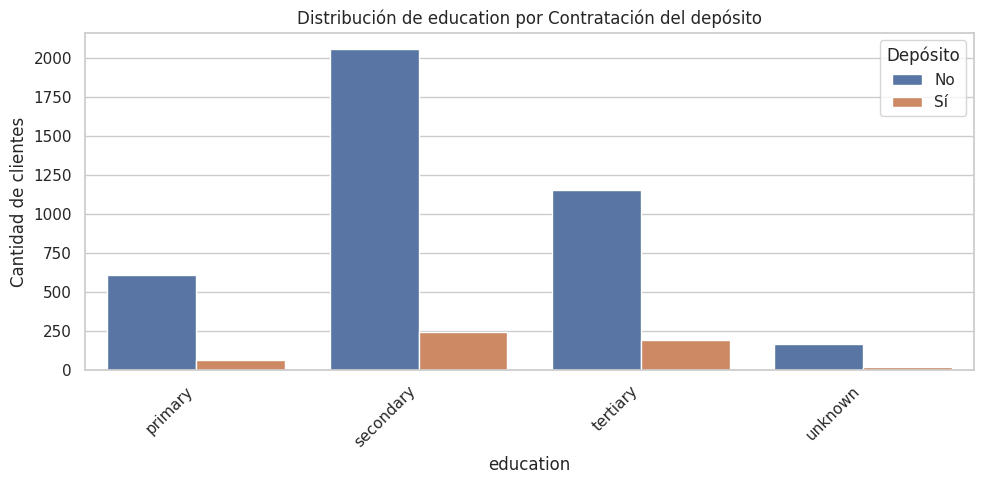

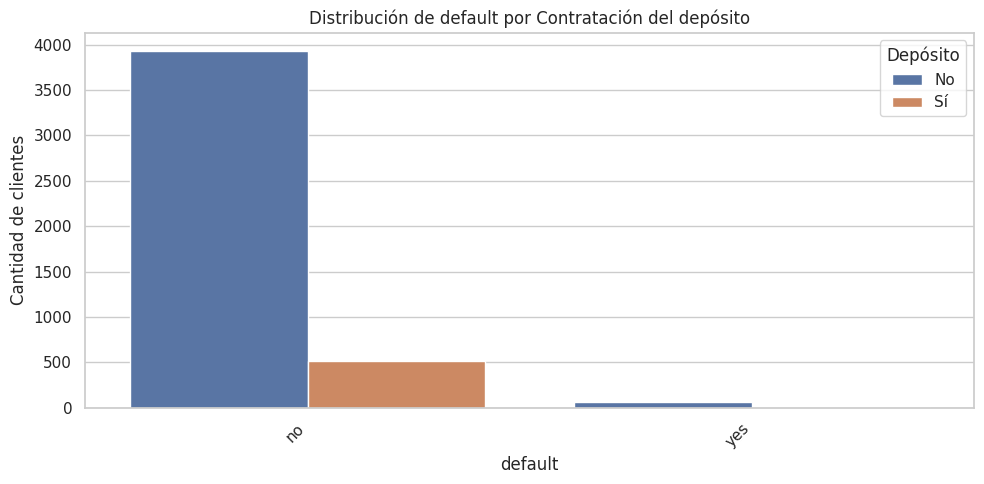

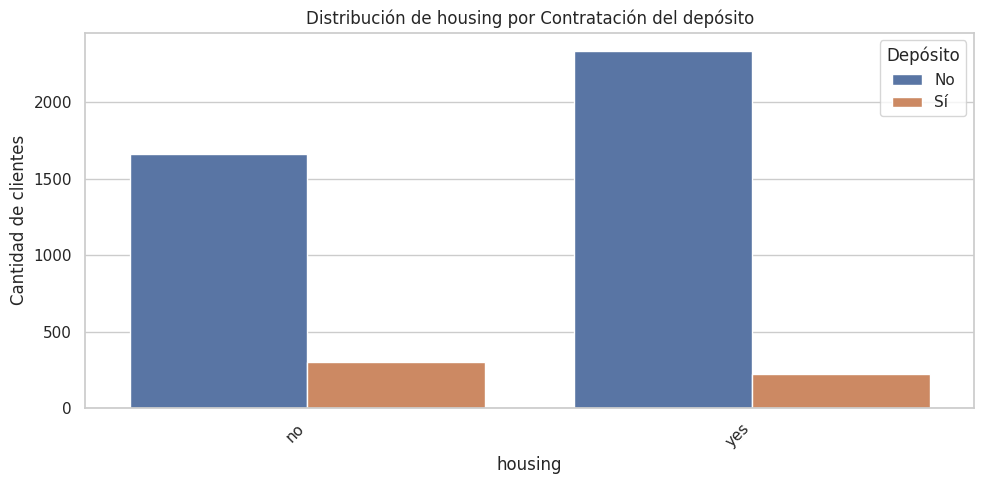

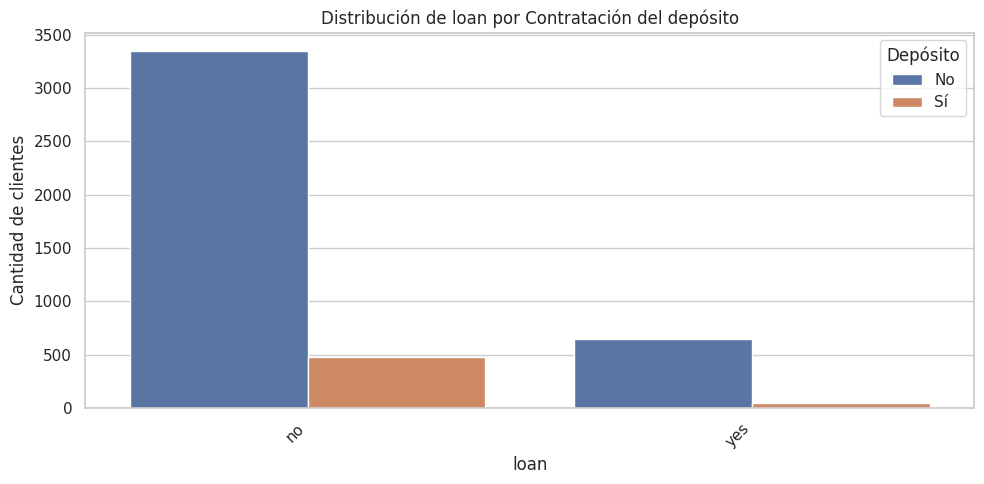

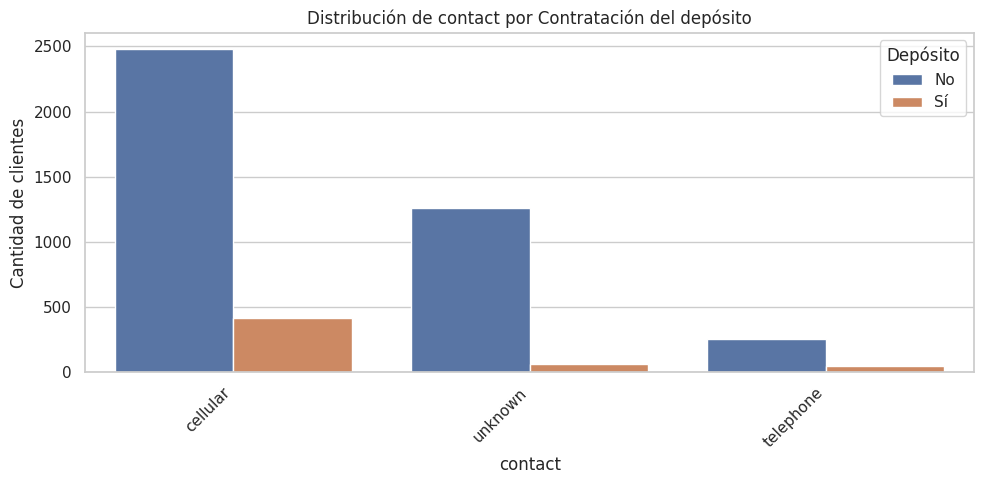

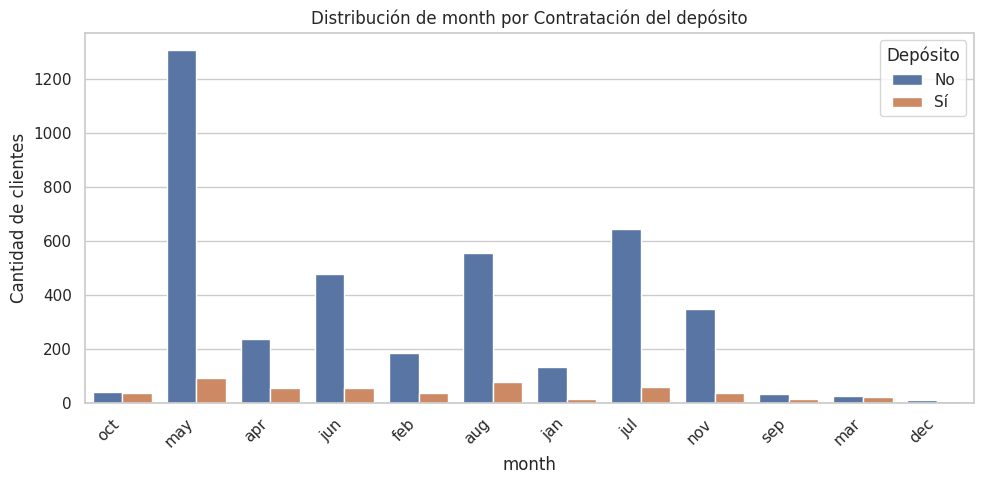

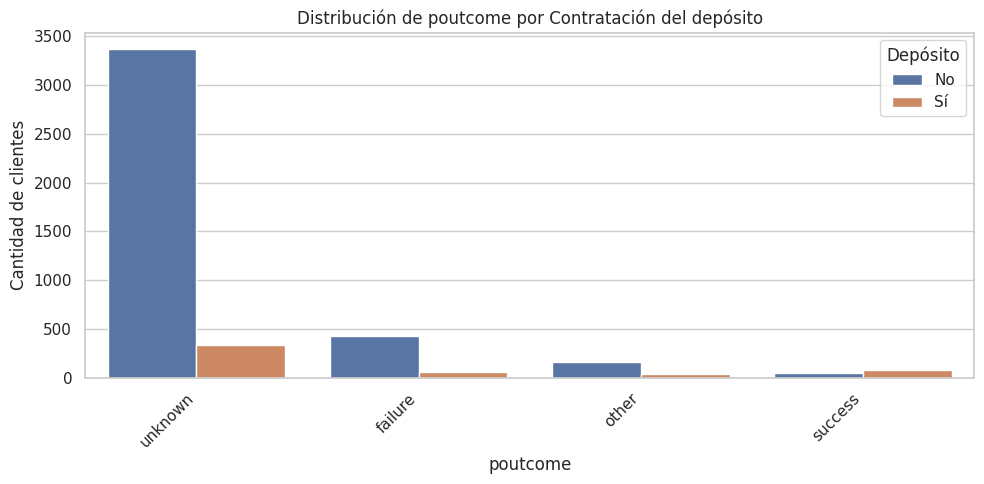

In [48]:
# Countplots de variables categóricas por variable objetivo
for col in categorical_cols_eda:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, data=df, hue='y')
    plt.title(f'Distribución de {col} por Contratación del depósito')
    plt.xlabel(col)
    plt.ylabel('Cantidad de clientes')
    plt.legend(title='Depósito', labels=['No', 'Sí'])
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### 5.4. Matriz de Correlación

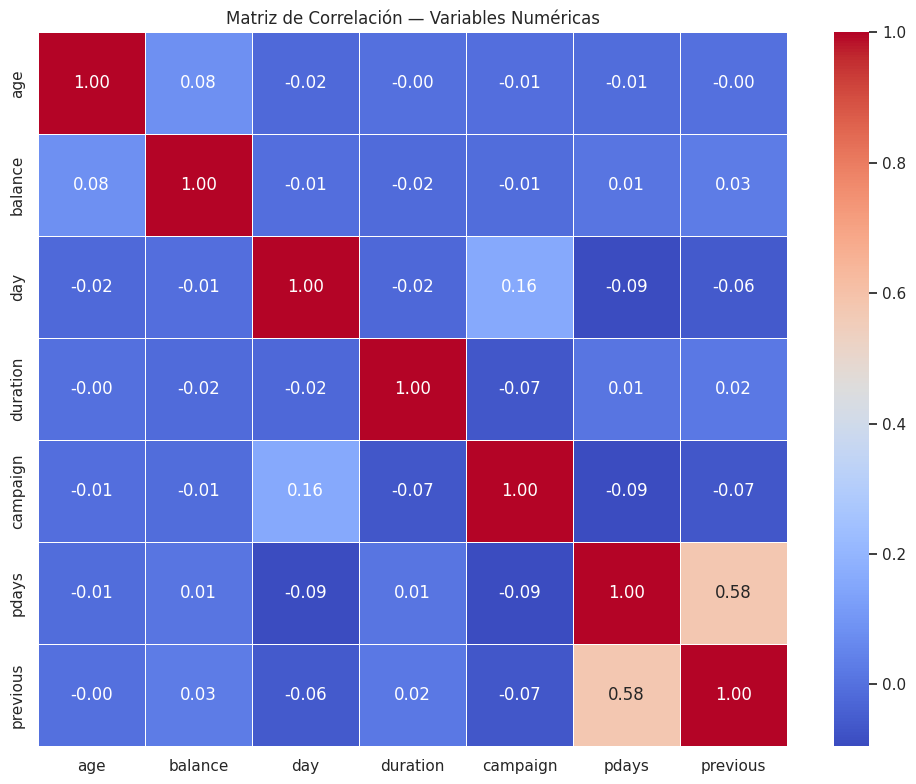

In [49]:
# Matriz de correlación de variables numéricas
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación — Variables Numéricas')
plt.tight_layout()
plt.show()

**Observaciones del EDA:**
- **Dataset desbalanceado:** Solo el ~11.5% de los clientes contrató el depósito. Un modelo que prediga "No" el 100% de las veces acertaría el 88%, por lo que el accuracy solo no es una métrica suficiente para evaluar el rendimiento.
- **Outliers en variables numéricas:** `balance` y `duration` presentan distribuciones asimétricas con casos extremos (ej: balances superiores a 70.000). Esto puede afectar el rendimiento del modelo.
- **`balance` y `age` muestran diferencias entre grupos:** Los boxplots muestran distribuciones distintas en edad y saldo bancario entre clientes que contrataron el depósito y los que no. Estas variables se consideran relevantes para el modelo.
- **Variables numéricas poco correlacionadas:** La matriz de correlación muestra correlaciones bajas entre las variables numéricas, lo cual es positivo para el modelo (poca multicolinealidad).

## 6. Preprocesamiento de Datos

Para preparar los datos para el modelo se realizan tres pasos:
1. **Exclusión de `duration`** por razones metodológicas (ver Hipótesis).
2. **Codificación de la variable objetivo** `y` a valores binarios (0/1) con `LabelEncoder`.
3. **Codificación de variables categóricas** con `pd.get_dummies()` (One-Hot Encoding).

Se utiliza pd.get_dummies() en esta etapa porque el Feature Selection posterior requiere que todas las variables estén en formato numérico para poder calcular correlaciones e importancia con Random Forest.
Como se vio en el notebook de Feature Engineering de clase, `get_dummies` es una forma directa de aplicar One-Hot Encoding desde Pandas.


In [50]:
# Excluimos 'duration' por razones metodológicas (ver hipótesis)
df_model = df.drop('duration', axis=1).copy()
print(f'Columnas después de excluir duration: {df_model.shape[1]}')
print(f'Columnas: {df_model.columns.tolist()}')

Columnas después de excluir duration: 16
Columnas: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [51]:
# Convertir variable objetivo 'y' a binario (0/1)
df_model['y'] = LabelEncoder().fit_transform(df_model['y'])
print('Variable objetivo codificada:')
print(df_model['y'].value_counts())

Variable objetivo codificada:
y
0    4000
1     521
Name: count, dtype: int64


In [52]:
# Identificar variables categóricas y numéricas
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
numerical_cols = df_model.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('y')  # Excluir la variable objetivo

print(f'Variables categóricas ({len(categorical_cols)}): {categorical_cols}')
print(f'Variables numéricas ({len(numerical_cols)}): {numerical_cols}')

Variables categóricas (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Variables numéricas (6): ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']


In [53]:
# Codificar variables categóricas con One-Hot Encoding
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print(f'Shape después de One-Hot Encoding: {df_encoded.shape}')
df_encoded.head()

Shape después de One-Hot Encoding: (4521, 42)


,age,balance,day,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,30,1787,19,1,-1,0,0,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1,33,4789,11,1,339,4,0,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,35,1350,16,1,330,1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,30,1476,3,4,-1,0,0,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,59,0,5,1,-1,0,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True


In [54]:
# Definir X (features) e y (variable objetivo)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

print(f'Features (X): {X.shape}')
print(f'Target (y): {y.shape}')
print(f'\nTotal de características: {X.shape[1]}')

Features (X): (4521, 41)
Target (y): (4521,)

Total de características: 41


**Resumen del preprocesamiento:**
- Se excluyó `duration` porque no está disponible antes de la llamada.
- Se codificó `y` a binario (0/1) con `LabelEncoder`.
- Se aplicó One-Hot Encoding (`get_dummies`) a las variables categóricas.

## 7. Feature Selection

Para cumplir con el apartado (i) de la consigna, se aplica un método de selección de variables para reducir la dimensionalidad del dataset. Se utilizan dos de los tres enfoques vistos en clase:

1. **Filter Method (Método de filtrado):** Análisis de correlación con la variable objetivo.

2. **Embedded Method (Método embebido):** Importancia de características mediante un Random Forest preliminar, utilizando el atributo `.feature_importances_` para rankear las variables que más reducen la impureza de los nodos.

Se seleccionan las features más relevantes según el segundo enfoque para entrenar el modelo final.

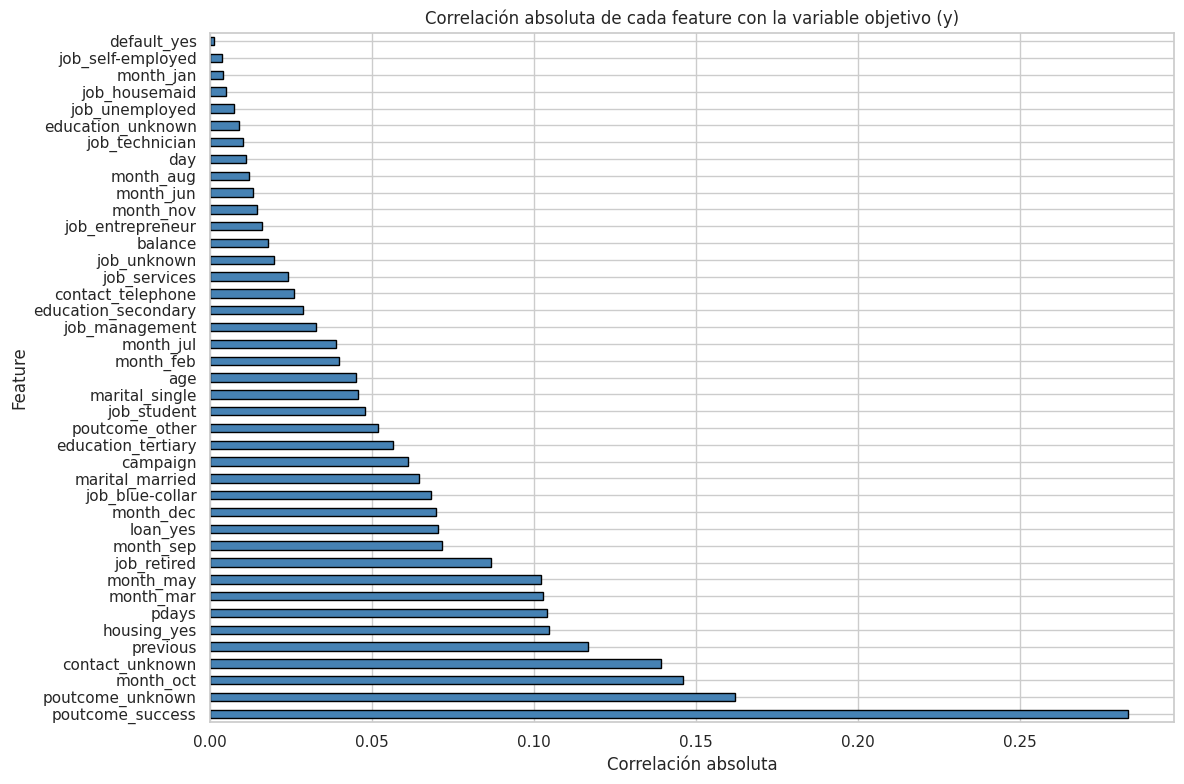

Top 15 features por correlación:
poutcome_success    0.283481
poutcome_unknown    0.162038
month_oct           0.145964
contact_unknown     0.139399
previous            0.116714
housing_yes         0.104683
pdays               0.104087
month_mar           0.102716
month_may           0.102077
job_retired         0.086675
month_sep           0.071510
loan_yes            0.070517
month_dec           0.069884
job_blue-collar     0.068147
marital_married     0.064643
dtype: float64


In [55]:
# Etapa 1: Correlación de cada feature con la variable objetivo
correlations = X.corrwith(y).abs().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
correlations.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Correlación absoluta de cada feature con la variable objetivo (y)')
plt.xlabel('Correlación absoluta')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Top 15 features por correlación:')
print(correlations.head(15))

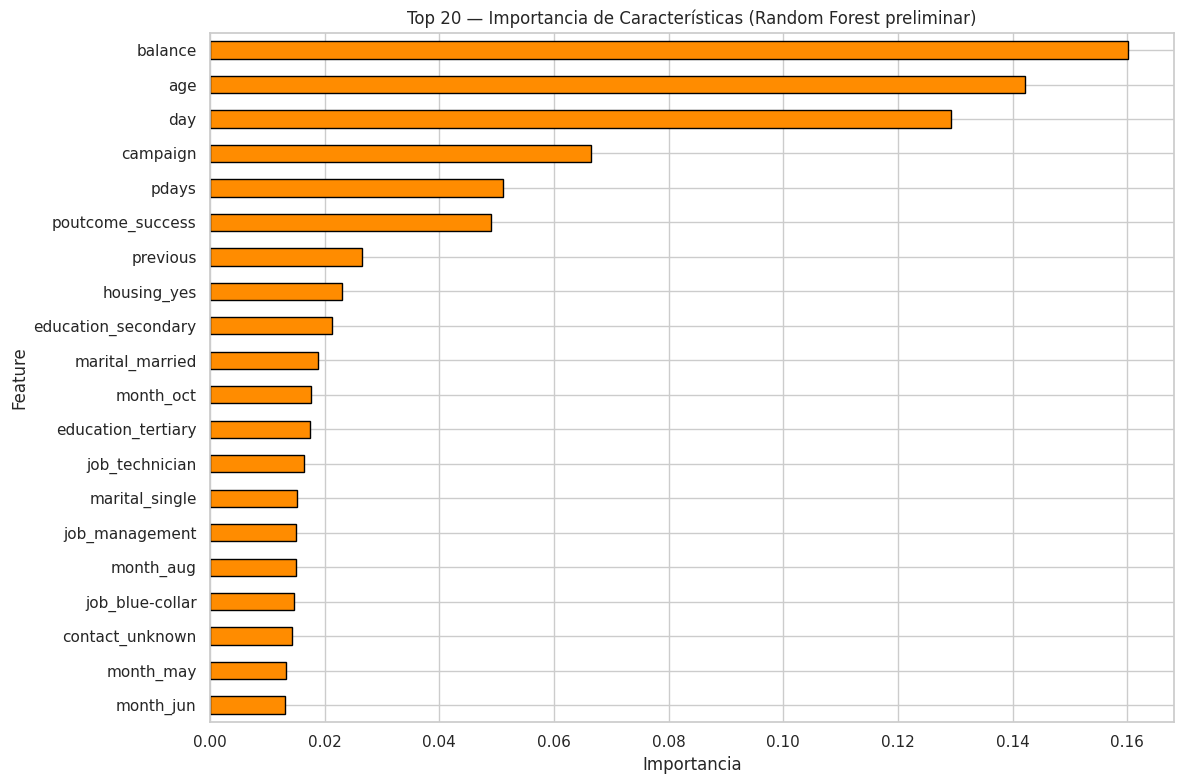

Top 15 features por importancia RF:
balance                0.160146
age                    0.142194
day                    0.129333
campaign               0.066532
pdays                  0.051147
poutcome_success       0.048972
previous               0.026506
housing_yes            0.023128
education_secondary    0.021347
marital_married        0.018812
month_oct              0.017715
education_tertiary     0.017443
job_technician         0.016492
marital_single         0.015245
job_management         0.014995
dtype: float64


In [56]:
# Etapa 2: Importancia de características con Random Forest preliminar
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X, y)

importances = pd.Series(rf_temp.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
importances.head(20).plot(kind='barh', color='darkorange', edgecolor='black')
plt.title('Top 20 — Importancia de Características (Random Forest preliminar)')
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 15 features por importancia RF:')
print(importances.head(15))

In [57]:
# Selección final: top 15 features por importancia del Random Forest
n_features = 15
selected_features = importances.head(n_features).index.tolist()

print(f'Features seleccionadas ({n_features}):')
for i, feat in enumerate(selected_features, 1):
    print(f'  {i}. {feat}')

# Reducir X a las features seleccionadas
X_selected = X[selected_features]
print(f'\nShape original: {X.shape}')
print(f'Shape reducido: {X_selected.shape}')
print(f'Reducción de dimensionalidad: {X.shape[1]} → {X_selected.shape[1]} features ({((1 - X_selected.shape[1]/X.shape[1])*100):.1f}% menos)')

Features seleccionadas (15):
  1. balance
  2. age
  3. day
  4. campaign
  5. pdays
  6. poutcome_success
  7. previous
  8. housing_yes
  9. education_secondary
  10. marital_married
  11. month_oct
  12. education_tertiary
  13. job_technician
  14. marital_single
  15. job_management

Shape original: (4521, 41)
Shape reducido: (4521, 15)
Reducción de dimensionalidad: 41 → 15 features (63.4% menos)


**Resultado del Feature Selection:**

Se aplicaron dos de los tres enfoques vistos en clase:
- **Filter Method:** Correlación con la variable objetivo.
- **Embedded Method:** `.feature_importances_` del Random Forest preliminar.

Se seleccionaron las 15 características con mayor importancia para entrenar el modelo final.

## 8. División de Datos (Train/Test Split)

In [58]:
# Dividir los datos en entrenamiento (75%) y prueba (25%)
# stratify=y mantiene la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} filas')
print(f'Conjunto de prueba: {X_test.shape[0]} filas')
print(f'\nProporción clase 1 (yes) en train: {y_train.mean():.4f}')
print(f'Proporción clase 1 (yes) en test:  {y_test.mean():.4f}')

Conjunto de entrenamiento: 3390 filas
Conjunto de prueba: 1131 filas

Proporción clase 1 (yes) en train: 0.1153
Proporción clase 1 (yes) en test:  0.1149


**Procedimiento:**

Se dividió el dataset en dos conjuntos: **Entrenamiento (75%)** y **Prueba (25%)**. Se utilizó `stratify=y` para mantener la proporción de clases en ambos conjuntos.

## 9. Construcción y Entrenamiento del Modelo (Random Forest)

In [59]:
# Crear el pipeline: preprocesamiento (escalado) + modelo
from sklearn.pipeline import Pipeline

model_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Entrenar el pipeline completo
model_pipeline.fit(X_train, y_train)

print('Pipeline entrenado correctamente (StandardScaler + RandomForestClassifier).')

Pipeline entrenado correctamente (StandardScaler + RandomForestClassifier).


In [60]:
# Predicciones sobre el conjunto de prueba
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

print(f'Predicciones realizadas: {len(y_pred)} observaciones')

Predicciones realizadas: 1131 observaciones


**Procedimiento:**

Se utilizó `RandomForestClassifier` con 100 estimadores (árboles de decisión). Siguiendo los conceptos clave de la API de Scikit-learn vistos en clase:

- `RandomForestClassifier()` es un **Estimador**: un objeto que puede estimar parámetros basándose en un dataset. Todos los estimadores implementan el método `fit()`.
- **`.fit(X_train, y_train)`**: Entrena el estimador. `X` son los datos (features) e `y` es el objetivo (target). El modelo aprende los patrones del conjunto de entrenamiento.
- Como también es un **Predictor**, implementa el método `predict()` para realizar predicciones sobre nuevos datos nunca antes vistos.
- **`.predict(X_test)`**: Genera las predicciones de clase (0 o 1).
- **`.predict_proba(X_test)`**: Devuelve las probabilidades de pertenecer a cada clase, necesarias para calcular la curva ROC y el AUC.

El parámetro `random_state=42` asegura que los resultados sean los mismos cada vez que ejecutamos el código (reproducibilidad).

## 10. Evaluación del Modelo

### 10.1. Accuracy

In [61]:
accuracy = accuracy_score(y_test, y_pred)
print(f"--- Accuracy Score ---")
print(f"Accuracy en el conjunto de prueba: {accuracy:.4f}")

--- Accuracy Score ---
Accuracy en el conjunto de prueba: 0.8815


### 10.2. Matriz de Confusión


--- Matriz de Confusión ---


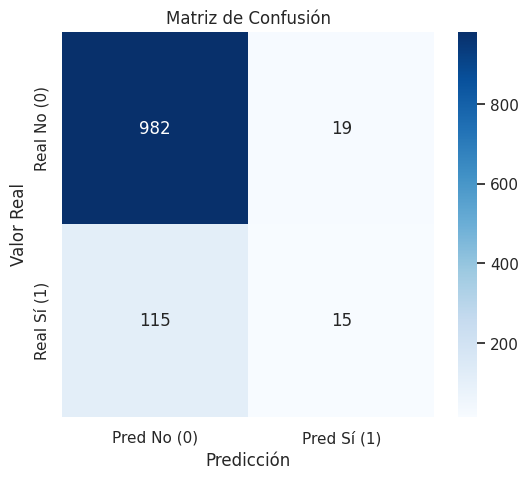

Verdaderos Negativos (TN): 982
Falsos Positivos (FP): 19
Falsos Negativos (FN): 115
Verdaderos Positivos (TP): 15


In [62]:
print("\n--- Matriz de Confusión ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No (0)', 'Pred Sí (1)'],
            yticklabels=['Real No (0)', 'Real Sí (1)'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()
print(f"Verdaderos Negativos (TN): {cm[0,0]}")
print(f"Falsos Positivos (FP): {cm[0,1]}")
print(f"Falsos Negativos (FN): {cm[1,0]}")
print(f"Verdaderos Positivos (TP): {cm[1,1]}")

### 10.3. Reporte de Clasificación (Precisión, Recall, F1-Score)

In [63]:
target_names = ['No contrató (0)', 'Sí contrató (1)']
print(classification_report(y_test, y_pred, target_names=target_names))

                 precision    recall  f1-score   support

No contrató (0)       0.90      0.98      0.94      1001
Sí contrató (1)       0.44      0.12      0.18       130

       accuracy                           0.88      1131
      macro avg       0.67      0.55      0.56      1131
   weighted avg       0.84      0.88      0.85      1131



### 10.4. Curva ROC y AUC

In [64]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

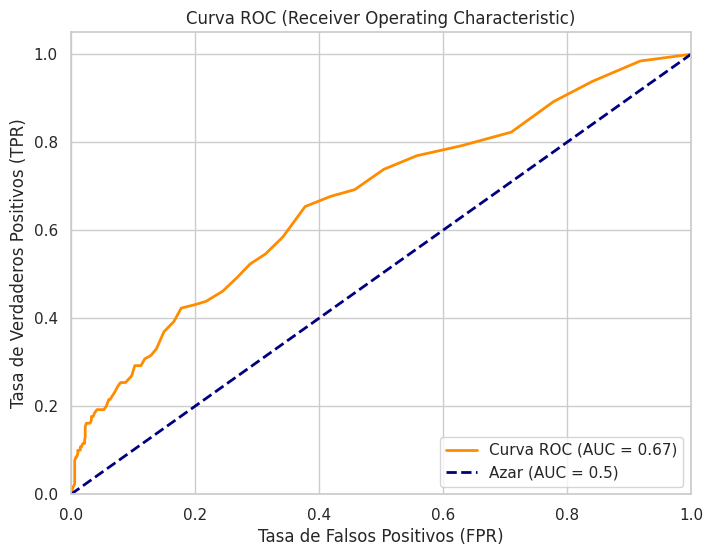

Área Bajo la Curva ROC (AUC): 0.6676


In [65]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.show()

print(f"Área Bajo la Curva ROC (AUC): {roc_auc:.4f}")

## 11. Análisis de Importancia de Características

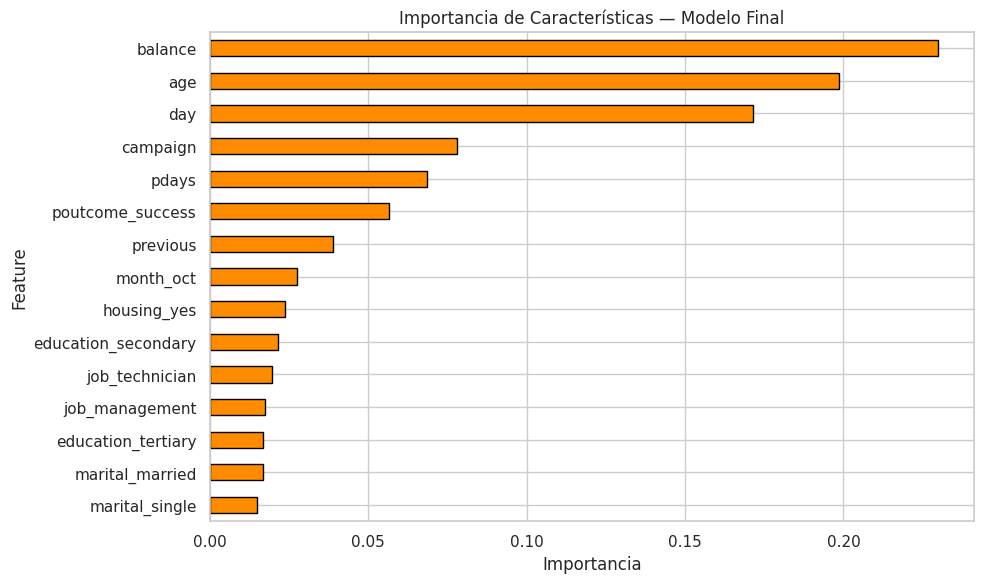

Top 5 características más importantes:
  1. balance: 0.2297
  2. age: 0.1985
  3. day: 0.1714
  4. campaign: 0.0780
  5. pdays: 0.0687


In [66]:
# Acceder al clasificador DENTRO del pipeline para obtener la importancia
rf_classifier = model_pipeline.named_steps['classifier']
feat_importances = pd.Series(rf_classifier.feature_importances_, index=X_train.columns)
feat_importances = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='darkorange', edgecolor='black')
plt.title('Importancia de Características — Modelo Final')
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 5 características más importantes:')
for i, (feat, imp) in enumerate(feat_importances.head(5).items(), 1):
    print(f'  {i}. {feat}: {imp:.4f}')

**Interpretación:**

El atributo `.feature_importances_` indica cuánto contribuye cada variable a las predicciones del modelo. Las características con mayor importancia son las que más contribuyen a reducir la impureza en los nodos del modelo, lo que sugiere mayor relevancia predictiva. Este análisis confirma que la selección de features realizada en la sección 7 fue adecuada.

## 12. Validación con Subconjuntos del Dataset Original

Se evalúa el modelo entrenando con distintos porcentajes del conjunto de entrenamiento (25%, 50%, 75% y 100%) para verificar la estabilidad de los resultados.

In [67]:
# Probar el modelo con subconjuntos del conjunto de entrenamiento
subsets = [0.25, 0.50, 0.75, 1.0]
results = []

for frac in subsets:
    if frac < 1.0:
        X_sub, _, y_sub, _ = train_test_split(
            X_train, y_train, train_size=frac, random_state=42, stratify=y_train
        )
    else:
        X_sub, y_sub = X_train, y_train

    pipe_sub = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    pipe_sub.fit(X_sub, y_sub)

    y_pred_sub = pipe_sub.predict(X_test)
    y_proba_sub = pipe_sub.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred_sub)
    auc_val = roc_auc_score(y_test, y_proba_sub)

    results.append({
        'Subconjunto': f'{int(frac*100)}% ({int(len(X_sub))} filas)',
        'Accuracy': round(acc, 4),
        'AUC-ROC': round(auc_val, 4)
    })

results_df = pd.DataFrame(results)
print('Resultados por subconjunto:')
print(results_df.to_string(index=False))

Resultados por subconjunto:
      Subconjunto  Accuracy  AUC-ROC
  25% (847 filas)    0.8833   0.6536
 50% (1695 filas)    0.8877   0.6744
 75% (2542 filas)    0.8833   0.6704
100% (3390 filas)    0.8815   0.6676


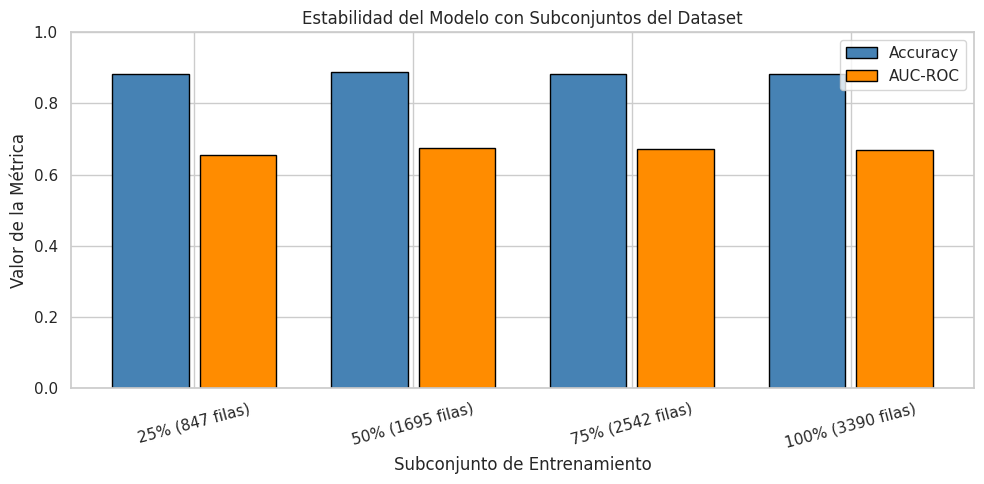

In [68]:
# Visualización de resultados por subconjunto
fig, ax1 = plt.subplots(figsize=(10, 5))

x_pos = range(len(results_df))
labels = [r['Subconjunto'] for r in results]

ax1.bar([p - 0.2 for p in x_pos], results_df['Accuracy'], width=0.35,
        label='Accuracy', color='steelblue', edgecolor='black')
ax1.bar([p + 0.2 for p in x_pos], results_df['AUC-ROC'], width=0.35,
        label='AUC-ROC', color='darkorange', edgecolor='black')

ax1.set_xlabel('Subconjunto de Entrenamiento')
ax1.set_ylabel('Valor de la Métrica')
ax1.set_title('Estabilidad del Modelo con Subconjuntos del Dataset')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels, rotation=15)
ax1.legend()
ax1.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**Interpretación:**

La consigna sugiere probar el modelo con subconjuntos del conjunto original. Se entrenó el modelo con distintos porcentajes del conjunto de entrenamiento (25%, 50%, 75% y 100%) para evaluar su estabilidad.

Este análisis permite verificar si el modelo sufre de sobreajuste (overfitting), es decir, si está aprendiendo de las casualidades de los datos (ruido) en lugar de los patrones reales (señal). Un modelo sobreajustado tendría buen rendimiento con muchos datos pero caería bruscamente con menos datos.

Los resultados muestran que las métricas se mantienen estables al variar el tamaño del conjunto de entrenamiento, lo que es consistente con una buena generalización del modelo, aunque el desbalance de clases puede influir en esta aparente estabilidad.

## 13. Conclusiones

In [69]:
print(f'Accuracy del modelo: {accuracy:.4f}')
print(f'AUC-ROC del modelo: {roc_auc:.4f}')

if accuracy > 0.75 and roc_auc > 0.5:
    print('\nRESULTADO: La hipótesis alternativa (H1) es soportada por los resultados.')
    print('El modelo supera el umbral de Accuracy (75%) y es mejor que el azar (AUC > 0.5).')
    print('Rechazamos la hipótesis nula (H0).')
else:
    print('\nRESULTADO: La hipótesis alternativa (H1) no es completamente soportada.')
    print('Se necesita revisar el modelo o los datos.')

Accuracy del modelo: 0.8815
AUC-ROC del modelo: 0.6676

RESULTADO: La hipótesis alternativa (H1) es soportada por los resultados.
El modelo supera el umbral de Accuracy (75%) y es mejor que el azar (AUC > 0.5).
Rechazamos la hipótesis nula (H0).


### Análisis de Resultados

**Métricas obtenidas:**
- **Accuracy:** 0.88 — El modelo clasifica correctamente el 88% de las observaciones.
- **AUC-ROC:** 0.67 — Capacidad discriminativa moderada, superior al azar.

**Interpretación:**
- La matriz de confusión muestra que el modelo predice bien la clase "No" (recall = 0.98) pero tiene dificultades con la clase "Sí" (recall = 0.12). Esto se debe al desbalance del dataset: solo el ~11.5% de los clientes contrató el depósito, por lo que el modelo tiende a predecir siempre "No".
- El accuracy de 0.88 puede resultar engañoso, como ya se vio al realizar el EDA, la distribucion de la variable objetivo es no = 0.8848, yes = 0.1152, por lo tanto un modelo que prediga no el 100% de las veces tendra un acierto del 88%. Esto puede ser particularmente problematico en un caso de marketing bancario donde seguramente se intenta conocer quienes sí van a contratar.

**Sobre la exclusión de `duration`:**
- Se excluyó deliberadamente porque solo se conoce después de la llamada y no puede usarse en un escenario predictivo real.

**Limitaciones:**
- El desbalance de clases es la principal limitación. En el Anexo se explora el uso de `class_weight='balanced'` como posible mejora.
- A pesar de esto, el modelo cumple con los umbrales de la hipótesis (Accuracy > 75% y AUC > 0.5).

## Anexo: Modelo con class_weight='balanced'

Para abordar la limitación del desbalance de clases identificada en las conclusiones, se entrena un segundo modelo utilizando el parámetro `class_weight='balanced'`, que penaliza más los errores en la clase minoritaria ("Sí").

In [70]:
# Pipeline con class_weight='balanced'
pipe_balanced = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])
pipe_balanced.fit(X_train, y_train)

y_pred_bal = pipe_balanced.predict(X_test)
y_proba_bal = pipe_balanced.predict_proba(X_test)[:, 1]

accuracy_bal = accuracy_score(y_test, y_pred_bal)
roc_auc_bal = roc_auc_score(y_test, y_proba_bal)

print('--- Modelo Balanceado ---')
print(f'Accuracy: {accuracy_bal:.4f}')
print(f'AUC-ROC: {roc_auc_bal:.4f}')

--- Modelo Balanceado ---
Accuracy: 0.8877
AUC-ROC: 0.6741


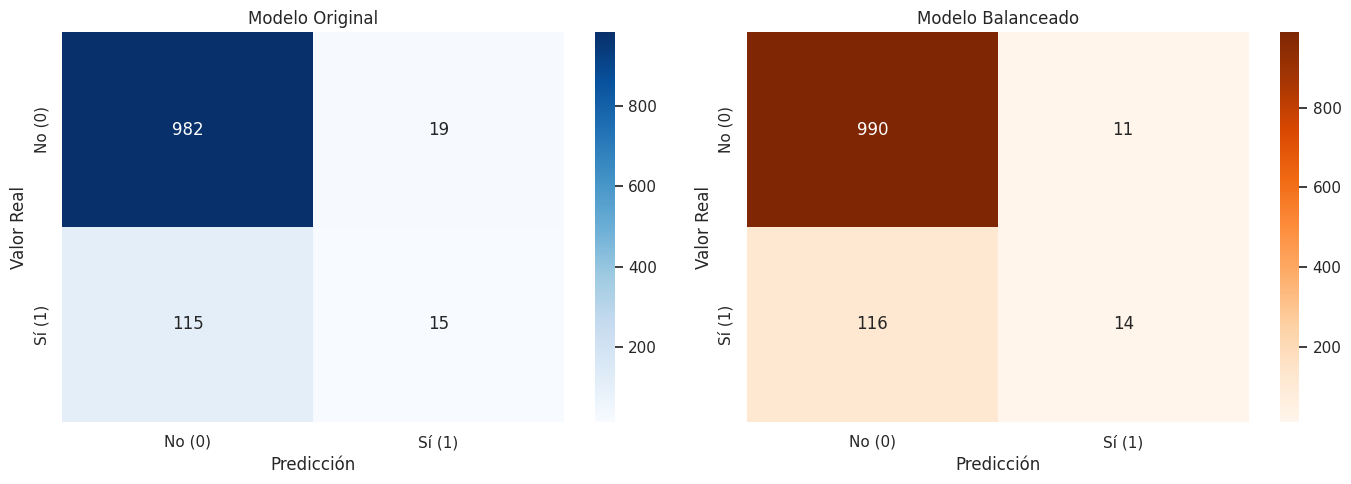

In [71]:
# Comparación de matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No (0)', 'Sí (1)'], yticklabels=['No (0)', 'Sí (1)'], ax=axes[0])
axes[0].set_title('Modelo Original')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor Real')

sns.heatmap(confusion_matrix(y_test, y_pred_bal), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No (0)', 'Sí (1)'], yticklabels=['No (0)', 'Sí (1)'], ax=axes[1])
axes[1].set_title('Modelo Balanceado')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

In [72]:
# Comparación de reportes de clasificación
print('=== Modelo Original ===')
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Sí (1)']))

print('=== Modelo Balanceado ===')
print(classification_report(y_test, y_pred_bal, target_names=['No (0)', 'Sí (1)']))

=== Modelo Original ===
              precision    recall  f1-score   support

      No (0)       0.90      0.98      0.94      1001
      Sí (1)       0.44      0.12      0.18       130

    accuracy                           0.88      1131
   macro avg       0.67      0.55      0.56      1131
weighted avg       0.84      0.88      0.85      1131

=== Modelo Balanceado ===
              precision    recall  f1-score   support

      No (0)       0.90      0.99      0.94      1001
      Sí (1)       0.56      0.11      0.18       130

    accuracy                           0.89      1131
   macro avg       0.73      0.55      0.56      1131
weighted avg       0.86      0.89      0.85      1131



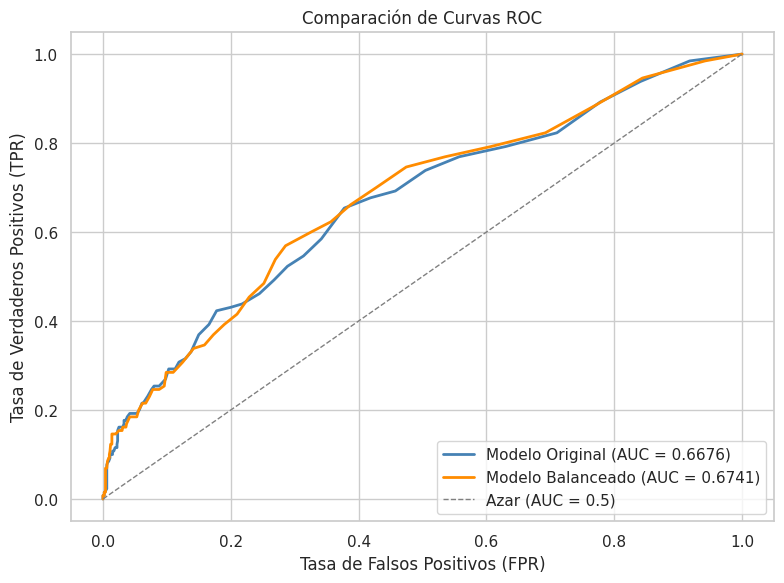

In [73]:
# Comparación de curvas ROC
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_proba_bal)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Modelo Original (AUC = {roc_auc:.4f})')
plt.plot(fpr_bal, tpr_bal, color='darkorange', lw=2, label=f'Modelo Balanceado (AUC = {roc_auc_bal:.4f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Azar (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Comparación de Curvas ROC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [74]:
# Tabla comparativa resumen
report_orig = classification_report(y_test, y_pred, target_names=['No (0)', 'Sí (1)'], output_dict=True)
report_bal = classification_report(y_test, y_pred_bal, target_names=['No (0)', 'Sí (1)'], output_dict=True)

comparacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'AUC-ROC', 'Recall clase Sí', 'Precision clase Sí', 'F1 clase Sí'],
    'Modelo Original': [
        accuracy, roc_auc,
        report_orig['Sí (1)']['recall'],
        report_orig['Sí (1)']['precision'],
        report_orig['Sí (1)']['f1-score']
    ],
    'Modelo Balanceado': [
        accuracy_bal, roc_auc_bal,
        report_bal['Sí (1)']['recall'],
        report_bal['Sí (1)']['precision'],
        report_bal['Sí (1)']['f1-score']
    ]
})
print('Tabla comparativa:')
print(comparacion.to_string(index=False))

Tabla comparativa:
           Métrica  Modelo Original  Modelo Balanceado
          Accuracy         0.881521           0.887710
           AUC-ROC         0.667605           0.674084
   Recall clase Sí         0.115385           0.107692
Precision clase Sí         0.441176           0.560000
       F1 clase Sí         0.182927           0.180645


### Conclusión del Anexo

La comparación entre ambos modelos evidencia el trade-off entre accuracy general y capacidad de detectar la clase minoritaria:

- **Modelo Original:** Accuracy alto pero recall muy bajo en la clase "Sí". En la práctica, casi no detecta a los clientes que van a contratar.
- **Modelo Balanceado:** El recall de la clase "Sí" mejora significativamente, a costa de una caída en el accuracy general y más falsos positivos.

Para un caso de uso real de marketing bancario, el modelo balanceado es más útil: es preferible llamar a algunos clientes que no van a contratar (falsos positivos) que perder clientes que sí habrían contratado (falsos negativos). La elección del modelo depende del costo relativo de cada tipo de error.